## 3. LiDAR-Guided DUSt3R Geometry Optimization for BEV Generation
Goal: Use Waymo LiDAR GT to refine DUSt3R pointmaps without retraining DUSt3R weights. We test three post-processing strategies: global scale correction, Sim(3) alignment, and local depth correction.

In [67]:
# Cell 1: Basic setup and paths

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook is under: project_root/notebooks/
PROJECT_ROOT = Path("..").resolve()

SELECTED_FRAME_DIR = PROJECT_ROOT / "data" / "selected_frame" / "frame_000030"
DUST3R_DIR = Path("./dust3r_output/frame_000030_5view").resolve()

LIDAR_DIR = PROJECT_ROOT / "data" / "lidar"
CALIB_DIR = PROJECT_ROOT / "data" / "calibration"


required_files = {
    "selected frame meta": SELECTED_FRAME_DIR / "meta.json",
    "front image": SELECTED_FRAME_DIR / "front.png",
    "front_left image": SELECTED_FRAME_DIR / "front_left.png",
    "front_right image": SELECTED_FRAME_DIR / "front_right.png",
    "side_left image": SELECTED_FRAME_DIR / "side_left.png",
    "side_right image": SELECTED_FRAME_DIR / "side_right.png",

    "DUSt3R imgs": DUST3R_DIR / "imgs.npy",
    "DUSt3R pts3d": DUST3R_DIR / "pts3d.npy",
    "DUSt3R conf": DUST3R_DIR / "raw_conf_maps.npy",
    "DUSt3R focals": DUST3R_DIR / "focals.npy",
    "DUSt3R poses": DUST3R_DIR / "poses.npy",
    "DUSt3R view names": DUST3R_DIR / "view_names.npy",
}

lidar_files = list(LIDAR_DIR.glob("*.parquet"))
calib_files = list(CALIB_DIR.glob("*.parquet"))


In [62]:
# Cell 2: Select exact parquet files for the current segment

SEGMENT_ID = "1022527355599519580_4866_960_4886_960"

def find_one_file(folder, pattern):
    matches = list(folder.glob(pattern))
    if len(matches) == 0:
        raise FileNotFoundError(f"No file found for pattern: {pattern}")
    if len(matches) > 1:
        print("Warning: multiple matches found:")
        for m in matches:
            print(" ", m.name)
        print("Using first match.")
    return matches[0]

camera_calib_path = find_one_file(CALIB_DIR, f"*camera_calibration*{SEGMENT_ID}.parquet")

lidar_path = find_one_file(LIDAR_DIR, f"*training_lidar_{SEGMENT_ID}.parquet")
lidar_calib_path = find_one_file(LIDAR_DIR, f"*lidar_calibration*{SEGMENT_ID}.parquet")
lidar_camera_proj_path = find_one_file(LIDAR_DIR, f"*lidar_camera_projection*{SEGMENT_ID}.parquet")
lidar_pose_path = find_one_file(LIDAR_DIR, f"*lidar_pose*{SEGMENT_ID}.parquet")
vehicle_pose_path = find_one_file(LIDAR_DIR, f"*vehicle_pose*{SEGMENT_ID}.parquet")

paths = {
    "camera_calib": camera_calib_path,
    "lidar": lidar_path,
    "lidar_calib": lidar_calib_path,
    "lidar_camera_projection": lidar_camera_proj_path,
    "lidar_pose": lidar_pose_path,
    "vehicle_pose": vehicle_pose_path,
}

for name, path in paths.items():
    print(f"{name:25s}: {path.name}")

camera_calib             : training_camera_calibration_1022527355599519580_4866_960_4886_960.parquet
lidar                    : training_lidar_1022527355599519580_4866_960_4886_960.parquet
lidar_calib              : training_lidar_calibration_1022527355599519580_4866_960_4886_960.parquet
lidar_camera_projection  : training_lidar_camera_projection_1022527355599519580_4866_960_4886_960.parquet
lidar_pose               : training_lidar_pose_1022527355599519580_4866_960_4886_960.parquet
vehicle_pose             : training_vehicle_pose_1022527355599519580_4866_960_4886_960.parquet


In [69]:
# Cell 3: Load selected frame metadata

meta_path = SELECTED_FRAME_DIR / "meta.json"

with open(meta_path, "r") as f:
    frame_meta = json.load(f)

print("meta keys:")
print(list(frame_meta.keys()))

print("\nmeta content:")
print("timestamp_micros:", frame_meta["timestamp_micros"])
print("camera ids/names:", frame_meta.get("camera_ids", frame_meta.get("camera_names", "N/A")))

meta keys:
['frame_index', 'timestamp_micros', 'cameras']

meta content:
timestamp_micros: 1511379226161595
camera ids/names: N/A


In [71]:
# Cell 4: Inspect available timestamps using lightweight columns only

FRAME_TS = int(frame_meta["timestamp_micros"])
print("Selected frame timestamp:", FRAME_TS)

key_cols_lidar = [
    "key.segment_context_name",
    "key.frame_timestamp_micros",
    "key.laser_name",
]
key_cols_pose = [
    "key.segment_context_name",
    "key.frame_timestamp_micros",
]
lidar_keys = pd.read_parquet(
    lidar_path,
    columns=key_cols_lidar,
    engine="pyarrow"
)
lidar_proj_keys = pd.read_parquet(
    lidar_camera_proj_path,
    columns=key_cols_lidar,
    engine="pyarrow"
)
vehicle_pose_keys = pd.read_parquet(
    vehicle_pose_path,
    columns=key_cols_pose,
    engine="pyarrow"
)
lidar_pose_keys = pd.read_parquet(
    lidar_pose_path,
    columns=key_cols_lidar,
    engine="pyarrow"
)

for name, df in [
    ("lidar", lidar_keys),
    ("lidar_camera_projection", lidar_proj_keys),
    ("vehicle_pose", vehicle_pose_keys),
    ("lidar_pose", lidar_pose_keys),
]:
    ts_unique = sorted(df["key.frame_timestamp_micros"].unique())
    print("=" * 60)
    print(name)
    print("num unique timestamps:", len(ts_unique))
    print("contains selected timestamp:", FRAME_TS in ts_unique)
    
    # nearest timestamp diagnostic
    nearest = min(ts_unique, key=lambda x: abs(x - FRAME_TS))
    print("nearest timestamp:", nearest)
    print("delta:", nearest - FRAME_TS)

Selected frame timestamp: 1511379226161595
lidar
num unique timestamps: 198
contains selected timestamp: True
nearest timestamp: 1511379226161595
delta: 0
lidar_camera_projection
num unique timestamps: 198
contains selected timestamp: True
nearest timestamp: 1511379226161595
delta: 0
vehicle_pose
num unique timestamps: 198
contains selected timestamp: True
nearest timestamp: 1511379226161595
delta: 0
lidar_pose
num unique timestamps: 198
contains selected timestamp: True
nearest timestamp: 1511379226161595
delta: 0


In [ ]:
# Cell 5: Inspect selected-frame LiDAR range images and camera projection images
# 每个 LiDAR sensor 的 range image / projection image shape
# 每个 sensor 有多少有效 range 点
# 每个 sensor 有多少点能投影到 camera
# top LiDAR 是否主导可用 projected samples

import numpy as np
import pandas as pd
RANGE_VALUES_COL = "[LiDARComponent].range_image_return1.values"
RANGE_SHAPE_COL = "[LiDARComponent].range_image_return1.shape"

PROJ_VALUES_COL = "[LiDARCameraProjectionComponent].range_image_return1.values"
PROJ_SHAPE_COL = "[LiDARCameraProjectionComponent].range_image_return1.shape"


def reshape_from_values_and_shape(values, shape):
    """
    Convert flattened Waymo parquet values + shape into a numpy array.
    """
    arr = np.asarray(values)
    shape = tuple(np.asarray(shape, dtype=int).tolist())
    return arr.reshape(shape)


summary_rows = []

for laser_name in sorted(lidar_frame_df["key.laser_name"].unique()):
    # Get LiDAR range row and projection row for this laser
    lidar_row = lidar_frame_df[lidar_frame_df["key.laser_name"] == laser_name].iloc[0]
    proj_row = lidar_proj_frame_df[lidar_proj_frame_df["key.laser_name"] == laser_name].iloc[0]

    # Reshape range image
    range_img = reshape_from_values_and_shape(
        lidar_row[RANGE_VALUES_COL],
        lidar_row[RANGE_SHAPE_COL],
    )

    # Reshape camera projection image
    proj_img = reshape_from_values_and_shape(
        proj_row[PROJ_VALUES_COL],
        proj_row[PROJ_SHAPE_COL],
    )

    range_channel = range_img[..., 0]
    valid_range = np.isfinite(range_channel) & (range_channel > 0)

    valid_proj_any = np.any(proj_img != 0, axis=-1)
    valid_both = valid_range & valid_proj_any

    if valid_range.any():
        valid_ranges = range_channel[valid_range]
        range_min = float(valid_ranges.min())
        range_max = float(valid_ranges.max())
        range_mean = float(valid_ranges.mean())
    else:
        range_min = range_max = range_mean = np.nan

    summary_rows.append({
        "laser_name": laser_name,
        "range_shape": str(range_img.shape),
        "projection_shape": str(proj_img.shape),
        "projection_channels": proj_img.shape[-1],
        "valid_range_points": int(valid_range.sum()),
        "valid_projection_points": int(valid_proj_any.sum()),
        "valid_range_and_projection_points": int(valid_both.sum()),
        "valid_range_ratio": float(valid_range.mean()),
        "valid_projection_ratio": float(valid_proj_any.mean()),
        "range_min": range_min,
        "range_max": range_max,
        "range_mean": range_mean,
    })

inspection_df = pd.DataFrame(summary_rows)
display(inspection_df)

,laser_name,range_shape,projection_shape,projection_channels,valid_range_points,valid_projection_points,valid_range_and_projection_points,valid_range_ratio,valid_projection_ratio,range_min,range_max,range_mean
0,1,"(64, 2650, 4)","(64, 2650, 6)",6,144296,96119,96119,0.850802,0.566739,3.343389,74.989105,23.005365
1,2,"(200, 600, 4)","(200, 600, 6)",6,3639,581,581,0.030325,0.004842,0.639073,19.998037,3.125552
2,3,"(200, 600, 4)","(200, 600, 6)",6,4072,688,688,0.033933,0.005733,0.889824,19.990910,4.893655
3,4,"(200, 600, 4)","(200, 600, 6)",6,3899,546,546,0.032492,0.004550,0.939833,19.986568,4.165471
4,5,"(200, 600, 4)","(200, 600, 6)",6,4249,107,107,0.035408,0.000892,0.420426,19.948763,3.145391


The selected frame contains valid LiDAR range images and corresponding camera projection images. The top LiDAR (`laser_name=1`) provides the majority of usable projected points, with 96,119 points having both valid range and camera projection. The camera projection image has 6 channels, which appear to encode up to two camera projections per LiDAR point: `[camera_id_1, u_1, v_1, camera_id_2, u_2, v_2]`. The projected pixel coordinates are in the original Waymo image resolution, so they must be rescaled before indexing DUSt3R resized pointmaps.

In [75]:
# Cell 6: Build LiDAR-to-camera projected samples from range image and camera projection image

import numpy as np
import pandas as pd

# Column names from Waymo v2 parquet schema
RANGE_VALUES_COL = "[LiDARComponent].range_image_return1.values"
RANGE_SHAPE_COL = "[LiDARComponent].range_image_return1.shape"

PROJ_VALUES_COL = "[LiDARCameraProjectionComponent].range_image_return1.values"
PROJ_SHAPE_COL = "[LiDARCameraProjectionComponent].range_image_return1.shape"


def reshape_from_values_and_shape(values, shape):
    """
    Convert flattened Waymo parquet values + shape into a numpy array.
    """
    arr = np.asarray(values)
    shape = tuple(np.asarray(shape, dtype=int).tolist())
    return arr.reshape(shape)


# Build camera id -> camera name mapping from meta.json
camera_id_to_name = {}
camera_name_to_meta = {}

for cam in frame_meta["cameras"]:
    cam_id = int(cam["camera_id"])
    cam_name = cam["camera_name"]
    camera_id_to_name[cam_id] = cam_name
    camera_name_to_meta[cam_name] = cam

print("camera_id_to_name:", camera_id_to_name)


sample_rows = []

# Projection format is treated as:
# [camera_id_1, u_1, v_1, camera_id_2, u_2, v_2]
# Each LiDAR range-image pixel may have up to two camera projections.
for laser_name in sorted(lidar_frame_df["key.laser_name"].unique()):
    lidar_row = lidar_frame_df[lidar_frame_df["key.laser_name"] == laser_name].iloc[0]
    proj_row = lidar_proj_frame_df[lidar_proj_frame_df["key.laser_name"] == laser_name].iloc[0]

    range_img = reshape_from_values_and_shape(
        lidar_row[RANGE_VALUES_COL],
        lidar_row[RANGE_SHAPE_COL],
    )

    proj_img = reshape_from_values_and_shape(
        proj_row[PROJ_VALUES_COL],
        proj_row[PROJ_SHAPE_COL],
    )

    range_channel = range_img[..., 0]
    valid_range = np.isfinite(range_channel) & (range_channel > 0)

    for proj_slot in [0, 1]:
        base = proj_slot * 3

        cam_ids = proj_img[..., base + 0].astype(np.int32)
        u_orig = proj_img[..., base + 1]
        v_orig = proj_img[..., base + 2]

        valid_proj = valid_range & (cam_ids > 0)
        rr, cc = np.where(valid_proj)

        for r, c in zip(rr, cc):
            cam_id = int(cam_ids[r, c])
            cam_name = camera_id_to_name.get(cam_id, f"unknown_{cam_id}")

            sample_rows.append({
                "laser_name": int(laser_name),
                "proj_slot": int(proj_slot),
                "range_row": int(r),
                "range_col": int(c),
                "lidar_range": float(range_channel[r, c]),
                "camera_id": cam_id,
                "camera_name": cam_name,
                "u_orig": float(u_orig[r, c]),
                "v_orig": float(v_orig[r, c]),
            })


lidar_camera_samples = pd.DataFrame(sample_rows)

print("num LiDAR-camera projected samples:", len(lidar_camera_samples))

summary_camera = lidar_camera_samples["camera_name"].value_counts().rename_axis("camera_name").reset_index(name="num_samples")
summary_laser = lidar_camera_samples["laser_name"].value_counts().sort_index().rename_axis("laser_name").reset_index(name="num_samples")
summary_slot = lidar_camera_samples["proj_slot"].value_counts().sort_index().rename_axis("proj_slot").reset_index(name="num_samples")

print("\nSamples per camera:")
display(summary_camera)

print("\nSamples per laser:")
display(summary_laser)

print("\nSamples per projection slot:")
display(summary_slot)

camera_id_to_name: {1: 'front', 2: 'front_left', 3: 'front_right', 4: 'side_left', 5: 'side_right'}
num LiDAR-camera projected samples: 107034

Samples per camera:


,camera_name,num_samples
0,side_left,22979
1,front_right,22928
2,front_left,22572
3,side_right,20227
4,front,18328



Samples per laser:


,laser_name,num_samples
0,1,104965
1,2,631
2,3,718
3,4,613
4,5,107



Samples per projection slot:


,proj_slot,num_samples
0,0,98041
1,1,8993


In [ ]:
# Cell 7: Load DUSt3R 5-view outputs

imgs_np = np.load(DUST3R_DIR / "imgs.npy", allow_pickle=True)
pts3d_np = np.load(DUST3R_DIR / "pts3d.npy", allow_pickle=True)
conf_np = np.load(DUST3R_DIR / "raw_conf_maps.npy", allow_pickle=True)
view_names = np.load(DUST3R_DIR / "view_names.npy", allow_pickle=True)

imgs_np = list(imgs_np)
pts3d_np = list(pts3d_np)
conf_np = list(conf_np)
view_names = [str(v) for v in view_names]

view_name_to_idx = {name: i for i, name in enumerate(view_names)}

print("view_names:", view_names)
print("view_name_to_idx:", view_name_to_idx)

for i, name in enumerate(view_names):
    print("-" * 50)
    print(f"[{i}] {name}")
    print("img shape:", imgs_np[i].shape)
    print("pts3d shape:", pts3d_np[i].shape)
    print("conf shape:", conf_np[i].shape)

view_names: ['side_left', 'front_left', 'front', 'front_right', 'side_right']
view_name_to_idx: {'side_left': 0, 'front_left': 1, 'front': 2, 'front_right': 3, 'side_right': 4}
--------------------------------------------------
[0] side_left
img shape: (224, 512, 3)
pts3d shape: (224, 512, 3)
conf shape: (224, 512)
--------------------------------------------------
[1] front_left
img shape: (336, 512, 3)
pts3d shape: (336, 512, 3)
conf shape: (336, 512)
--------------------------------------------------
[2] front
img shape: (336, 512, 3)
pts3d shape: (336, 512, 3)
conf shape: (336, 512)
--------------------------------------------------
[3] front_right
img shape: (336, 512, 3)
pts3d shape: (336, 512, 3)
conf shape: (336, 512)
--------------------------------------------------
[4] side_right
img shape: (224, 512, 3)
pts3d shape: (224, 512, 3)
conf shape: (224, 512)


In [76]:
# Cell 8: Map LiDAR original pixels to DUSt3R resized pixels

samples = lidar_camera_samples.copy()

# Build metadata maps from meta.json
camera_name_to_meta = {
    cam["camera_name"]: cam
    for cam in frame_meta["cameras"]
}

# Add original image size and DUSt3R resized size
orig_widths = []
orig_heights = []
dust3r_widths = []
dust3r_heights = []
view_indices = []

for _, row in samples.iterrows():
    cam_name = row["camera_name"]

    if cam_name not in camera_name_to_meta:
        orig_widths.append(np.nan)
        orig_heights.append(np.nan)
        dust3r_widths.append(np.nan)
        dust3r_heights.append(np.nan)
        view_indices.append(-1)
        continue

    if cam_name not in view_name_to_idx:
        orig_widths.append(np.nan)
        orig_heights.append(np.nan)
        dust3r_widths.append(np.nan)
        dust3r_heights.append(np.nan)
        view_indices.append(-1)
        continue

    meta = camera_name_to_meta[cam_name]
    view_idx = view_name_to_idx[cam_name]

    H_d, W_d = pts3d_np[view_idx].shape[:2]

    orig_widths.append(meta["width"])
    orig_heights.append(meta["height"])
    dust3r_widths.append(W_d)
    dust3r_heights.append(H_d)
    view_indices.append(view_idx)

samples["orig_width"] = orig_widths
samples["orig_height"] = orig_heights
samples["dust3r_width"] = dust3r_widths
samples["dust3r_height"] = dust3r_heights
samples["view_idx"] = view_indices

# -----------Original camera coordinates -> DUSt3R resized coordinates
samples["u_dust3r"] = np.round(
    samples["u_orig"] / samples["orig_width"] * samples["dust3r_width"]
).astype("Int64")

samples["v_dust3r"] = np.round(
    samples["v_orig"] / samples["orig_height"] * samples["dust3r_height"]
).astype("Int64")

# Valid pixel check
valid_pixel = (
    (samples["view_idx"] >= 0) &
    (samples["u_dust3r"] >= 0) &
    (samples["v_dust3r"] >= 0) &
    (samples["u_dust3r"] < samples["dust3r_width"]) &
    (samples["v_dust3r"] < samples["dust3r_height"])
)

samples_mapped = samples[valid_pixel].copy()

print("original samples:", len(samples))
print("valid mapped samples:", len(samples_mapped))
print("dropped samples:", len(samples) - len(samples_mapped))

print("\nMapped samples per camera:")
display(samples_mapped["camera_name"].value_counts())

print("\nOriginal / DUSt3R size check:")
display(
    samples_mapped[
        ["camera_name", "orig_width", "orig_height", "dust3r_width", "dust3r_height"]
    ].drop_duplicates().sort_values("camera_name")
)

original samples: 107034
valid mapped samples: 106950
dropped samples: 84

Mapped samples per camera:


camera_name
side_left      22962
front_right    22904
front_left     22557
side_right     20218
front          18309
Name: count, dtype: int64


Original / DUSt3R size check:


,camera_name,orig_width,orig_height,dust3r_width,dust3r_height
662,front,1920,1280,512,336
329,front_left,1920,1280,512,336
869,front_right,1920,1280,512,336
0,side_left,1920,886,512,224
1200,side_right,1920,886,512,224


In [77]:
# Cell 9: Sample DUSt3R pointmap and confidence at mapped pixels 这一格真正把 LiDAR samples 和 DUSt3R pointmap 接起来。

paired_rows = []

for cam_name, group in samples_mapped.groupby("camera_name"):
    view_idx = view_name_to_idx[cam_name]

    pts_map = pts3d_np[view_idx]   # H x W x 3
    conf_map = conf_np[view_idx]   # H x W

    u = group["u_dust3r"].astype(int).to_numpy()
    v = group["v_dust3r"].astype(int).to_numpy()

    pts = pts_map[v, u, :]         # N x 3
    conf_vals = conf_map[v, u]     # N

    group_out = group.copy()
    group_out["dust3r_x"] = pts[:, 0]
    group_out["dust3r_y"] = pts[:, 1]
    group_out["dust3r_z"] = pts[:, 2]
    group_out["dust3r_norm"] = np.linalg.norm(pts, axis=1)
    group_out["dust3r_conf"] = conf_vals

    paired_rows.append(group_out)

lidar_dust3r_pairs = pd.concat(paired_rows, axis=0).reset_index(drop=True)

# Remove invalid DUSt3R points
valid_dust3r = (
    np.isfinite(lidar_dust3r_pairs["dust3r_x"]) &
    np.isfinite(lidar_dust3r_pairs["dust3r_y"]) &
    np.isfinite(lidar_dust3r_pairs["dust3r_z"]) &
    np.isfinite(lidar_dust3r_pairs["dust3r_norm"]) &
    np.isfinite(lidar_dust3r_pairs["dust3r_conf"])
)

lidar_dust3r_pairs = lidar_dust3r_pairs[valid_dust3r].copy()

print("\nPairs per camera:")
display(lidar_dust3r_pairs["camera_name"].value_counts())

print("\nDust3R norm stats:")
display(lidar_dust3r_pairs["dust3r_norm"].describe())

print("\nLiDAR range stats:")
display(lidar_dust3r_pairs["lidar_range"].describe())

print("\nDust3R confidence stats:")
display(lidar_dust3r_pairs["dust3r_conf"].describe())


Pairs per camera:


camera_name
side_left      22962
front_right    22904
front_left     22557
side_right     20218
front          18309
Name: count, dtype: int64


Dust3R norm stats:


count    106950.000000
mean          0.236782
std           0.147288
min           0.055366
25%           0.122551
50%           0.221518
75%           0.297241
max           1.208926
Name: dust3r_norm, dtype: float64


LiDAR range stats:


count    106950.000000
mean         23.105812
std          13.915622
min           1.559114
25%          12.278609
50%          19.796843
75%          28.187517
max          74.989105
Name: lidar_range, dtype: float64


Dust3R confidence stats:


count    106950.000000
mean          5.292394
std           3.493411
min           1.000000
25%           2.445570
50%           4.392212
75%           7.558941
max          14.623116
Name: dust3r_conf, dtype: float64

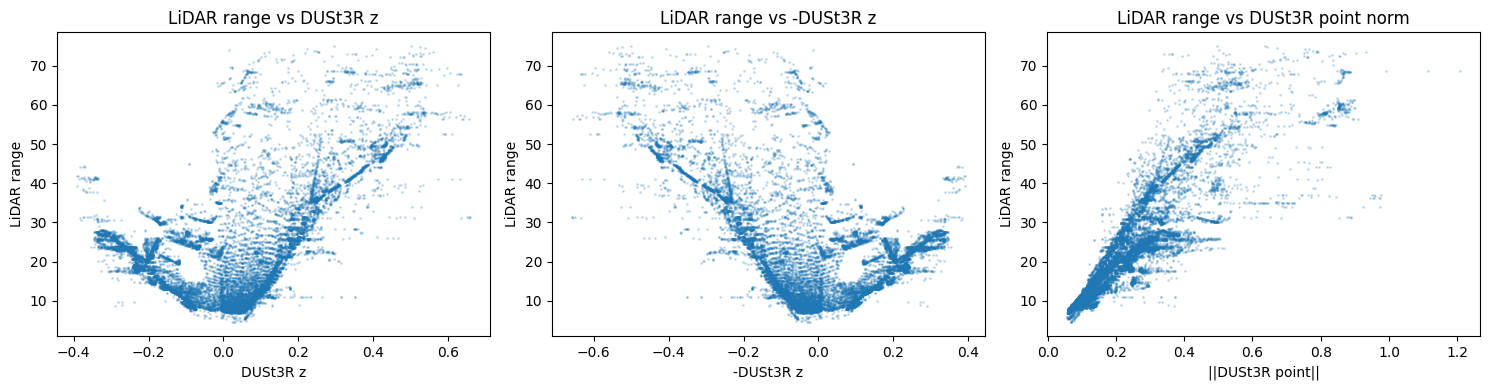

In [ ]:
# Cell 10: Quick sanity scatter plots for LiDAR range vs DUSt3R quantities

# Subsample for plotting
plot_df = lidar_dust3r_pairs.copy()

if len(plot_df) > 20000:
    plot_df = plot_df.sample(20000, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(plot_df["dust3r_z"], plot_df["lidar_range"], s=1, alpha=0.2)
axes[0].set_xlabel("DUSt3R z")
axes[0].set_ylabel("LiDAR range")
axes[0].set_title("LiDAR range vs DUSt3R z")

axes[1].scatter(-plot_df["dust3r_z"], plot_df["lidar_range"], s=1, alpha=0.2)
axes[1].set_xlabel("-DUSt3R z")
axes[1].set_ylabel("LiDAR range")
axes[1].set_title("LiDAR range vs -DUSt3R z")

axes[2].scatter(plot_df["dust3r_norm"], plot_df["lidar_range"], s=1, alpha=0.2)
axes[2].set_xlabel("||DUSt3R point||")
axes[2].set_ylabel("LiDAR range")
axes[2].set_title("LiDAR range vs DUSt3R point norm")

plt.tight_layout()
plt.show()

We successfully matched projected Waymo LiDAR samples with DUSt3R pointmaps at the pixel level. The scatter plots suggest that `||p_dust3r||` correlates better with LiDAR range than DUSt3R z or -z, making it the most reasonable starting signal for scale-only depth correction.

### 3.1 Scale Fitting
We fit a global scale factor `s` such that `s * ||p_dust3r||` best matches the metric LiDAR range. This provides the first LiDAR-guided correction to DUSt3R's up-to-scale geometry before BEV projection.

In [78]:
# Cell 11: Prepare samples for global scale fitting

scale_df = lidar_dust3r_pairs.copy()

# Basic validity filtering
valid = (
    np.isfinite(scale_df["lidar_range"]) &
    np.isfinite(scale_df["dust3r_norm"]) &
    np.isfinite(scale_df["dust3r_conf"]) &
    (scale_df["lidar_range"] > 0) &
    (scale_df["dust3r_norm"] > 0)
)

scale_df = scale_df[valid].copy()

print("valid samples for scale fitting:", len(scale_df))

print("\nKey statistics:")
stats_df = pd.DataFrame({
    "lidar_range": scale_df["lidar_range"].describe(),
    "dust3r_norm": scale_df["dust3r_norm"].describe(),
    "dust3r_conf": scale_df["dust3r_conf"].describe(),
})
display(stats_df)

print("\nSamples per camera:")
display(
    scale_df["camera_name"]
    .value_counts()
    .rename_axis("camera_name")
    .reset_index(name="num_samples")
)

valid samples for scale fitting: 106950

Key statistics:


,lidar_range,dust3r_norm,dust3r_conf
count,106950.000000,106950.000000,106950.000000
mean,23.105812,0.236782,5.292394
std,13.915622,0.147288,3.493411
min,1.559114,0.055366,1.000000
25%,12.278609,0.122551,2.445570
50%,19.796843,0.221518,4.392212
75%,28.187517,0.297241,7.558941
max,74.989105,1.208926,14.623116



Samples per camera:


,camera_name,num_samples
0,side_left,22962
1,front_right,22904
2,front_left,22557
3,side_right,20218
4,front,18309


Fit global scale factor, two versions:

Least-squares scale: s_ls = sum(d_dust3r * d_lidar) / sum(d_dust3r^2) 

Median-ratio scale: s_median = median(d_lidar / d_dust3r)

In [ ]:
# Cell 12: Fit global scale factor

x = scale_df["dust3r_norm"].to_numpy()   # DUSt3R arbitrary-scale depth-like quantity
y = scale_df["lidar_range"].to_numpy()   # metric LiDAR range

# Least-squares scale: minimize ||s*x - y||^2
scale_ls = np.sum(x * y) / (np.sum(x * x) + 1e-8)

# Robust median-ratio scale
scale_median = np.median(y / (x + 1e-8))

print("Global scale fitting results")
print("-" * 50)
print(f"least-squares scale: {scale_ls:.4f}")
print(f"median-ratio scale:  {scale_median:.4f}")

# Add predictions
scale_df["dust3r_scaled_ls"] = scale_ls * scale_df["dust3r_norm"]
scale_df["dust3r_scaled_median"] = scale_median * scale_df["dust3r_norm"]

# Error metrics
def compute_error_metrics(pred, target):
    err = pred - target
    abs_err = np.abs(err)
    sq_err = err ** 2
    
    return {
        "MAE": float(abs_err.mean()),
        "RMSE": float(np.sqrt(sq_err.mean())),
        "Median Abs Error": float(np.median(abs_err)),
        "Mean Relative Error": float((abs_err / (target + 1e-8)).mean()),
        "Median Relative Error": float(np.median(abs_err / (target + 1e-8))),
    }

metrics_ls = compute_error_metrics(
    scale_df["dust3r_scaled_ls"].to_numpy(),
    scale_df["lidar_range"].to_numpy()
)

metrics_median = compute_error_metrics(
    scale_df["dust3r_scaled_median"].to_numpy(),
    scale_df["lidar_range"].to_numpy()
)

metrics_df = pd.DataFrame([
    {"Method": "Least-squares scale", "Scale": scale_ls, **metrics_ls},
    {"Method": "Median-ratio scale", "Scale": scale_median, **metrics_median},
])

display(metrics_df)

Global scale fitting results
--------------------------------------------------
least-squares scale: 93.5132
median-ratio scale:  104.3305


,Method,Scale,MAE,RMSE,Median Abs Error,Mean Relative Error,Median Relative Error
0,Least-squares scale,93.513215,4.610047,6.894894,2.544019,0.189458,0.173081
1,Median-ratio scale,104.330526,4.751443,7.525854,3.103689,0.197196,0.141067


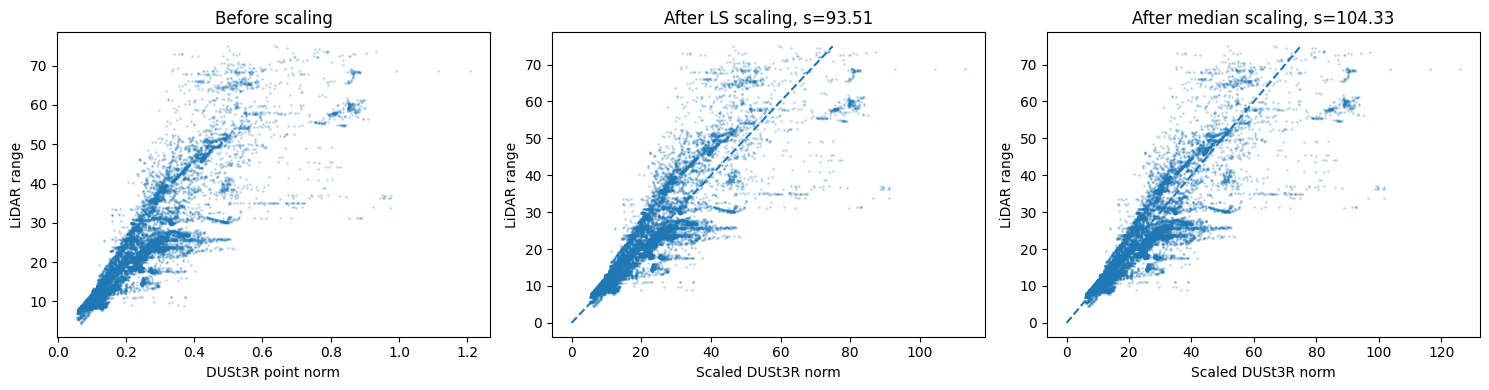

In [ ]:
# Cell 13: Visualize scale fitting result

plot_df = scale_df.copy()

if len(plot_df) > 20000:
    plot_df = plot_df.sample(20000, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Before scaling
axes[0].scatter(plot_df["dust3r_norm"], plot_df["lidar_range"], s=1, alpha=0.2)
axes[0].set_xlabel("DUSt3R point norm")
axes[0].set_ylabel("LiDAR range")
axes[0].set_title("Before scaling")

# After least-squares scaling
axes[1].scatter(plot_df["dust3r_scaled_ls"], plot_df["lidar_range"], s=1, alpha=0.2)
axes[1].plot(
    [0, plot_df["lidar_range"].max()],
    [0, plot_df["lidar_range"].max()],
    linestyle="--"
)
axes[1].set_xlabel("Scaled DUSt3R norm")
axes[1].set_ylabel("LiDAR range")
axes[1].set_title(f"After LS scaling, s={scale_ls:.2f}")

# After median-ratio scaling
axes[2].scatter(plot_df["dust3r_scaled_median"], plot_df["lidar_range"], s=1, alpha=0.2)
axes[2].plot(
    [0, plot_df["lidar_range"].max()],
    [0, plot_df["lidar_range"].max()],
    linestyle="--"
)
axes[2].set_xlabel("Scaled DUSt3R norm")
axes[2].set_ylabel("LiDAR range")
axes[2].set_title(f"After median scaling, s={scale_median:.2f}")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 14: Fit scale factor per camera

camera_rows = []

for cam_name, group in scale_df.groupby("camera_name"):
    x_cam = group["dust3r_norm"].to_numpy()
    y_cam = group["lidar_range"].to_numpy()
    
    s_ls_cam = np.sum(x_cam * y_cam) / (np.sum(x_cam * x_cam) + 1e-8)
    s_med_cam = np.median(y_cam / (x_cam + 1e-8))
    
    pred_ls = s_ls_cam * x_cam
    metrics = compute_error_metrics(pred_ls, y_cam)
    
    camera_rows.append({
        "camera_name": cam_name,
        "num_samples": len(group),
        "scale_ls": s_ls_cam,
        "scale_median": s_med_cam,
        **metrics,
    })

camera_scale_df = pd.DataFrame(camera_rows).sort_values("camera_name")
display(camera_scale_df)

,camera_name,num_samples,scale_ls,scale_median,MAE,RMSE,Median Abs Error,Mean Relative Error,Median Relative Error
0,front,18309,82.259447,104.252603,6.129177,8.334886,3.933522,0.226636,0.223542
1,front_left,22557,82.391426,91.457659,2.883337,3.676324,2.535757,0.158795,0.122064
2,front_right,22904,117.654238,118.392625,2.462107,4.309490,1.325745,0.089764,0.051959
3,side_left,22962,78.047627,80.937456,1.771163,2.608399,1.323016,0.105744,0.073861
4,side_right,20218,119.593199,117.316972,2.088915,4.317923,0.805189,0.071014,0.048827


The scale fitting result confirms that DUSt3R geometry has a strong global scale ambiguity: multiplying `||p_dust3r||` by roughly 100 brings it into the metric LiDAR range scale. However, per-camera scale differences indicate that global scaling alone is insufficient, motivating a full Sim(3) alignment with scale, rotation, and translation.

In this step, we apply the fitted scale to all DUSt3R pointmaps and regenerate BEV maps to test the effect of metric scale correction.

In [ ]:
# Cell 15: Apply global scale + confidence filtering to all DUSt3R pointmaps and merge

# Use the fitted global scale.
# LS scale has slightly lower MAE/RMSE in the current fitting result.
global_scale = scale_ls

# Use the best confidence threshold observed in the 5-view baseline ablation
conf_thresh = 1.9

scaled_all_points = []
scaled_all_colors = []
scaled_all_confs = []

for i, name in enumerate(view_names):
    pts = pts3d_np[i]       # H x W x 3, DUSt3R global-aligned pointmap
    img = imgs_np[i]        # H x W x 3, RGB in [0, 1]
    conf = conf_np[i]       # H x W raw confidence

    # Flatten each view into point list
    pts_flat = pts.reshape(-1, 3)
    colors_flat = img.reshape(-1, 3)
    conf_flat = conf.reshape(-1)

    # Remove invalid numerical points + apply confidence filtering
    valid = (
        np.isfinite(pts_flat).all(axis=1) &
        np.isfinite(colors_flat).all(axis=1) &
        np.isfinite(conf_flat) &
        (conf_flat >= conf_thresh)
    )

    pts_flat = pts_flat[valid]
    colors_flat = colors_flat[valid]
    conf_flat = conf_flat[valid]

    # Apply global metric scale after filtering
    pts_scaled = pts_flat * global_scale

    scaled_all_points.append(pts_scaled)
    scaled_all_colors.append(colors_flat)
    scaled_all_confs.append(conf_flat)

    print(f"{name:12s} kept points after conf >= {conf_thresh}: {len(pts_scaled)}")

scaled_points = np.concatenate(scaled_all_points, axis=0)
scaled_colors = np.concatenate(scaled_all_colors, axis=0)
scaled_confs = np.concatenate(scaled_all_confs, axis=0)

print("-" * 60)
print("global_scale:", global_scale)
print("conf_thresh:", conf_thresh)
print("scaled merged points:", scaled_points.shape)
print("scaled merged colors:", scaled_colors.shape)
print("scaled merged confs:", scaled_confs.shape)

print("scaled x range:", scaled_points[:, 0].min(), scaled_points[:, 0].max())
print("scaled y range:", scaled_points[:, 1].min(), scaled_points[:, 1].max())
print("scaled z range:", scaled_points[:, 2].min(), scaled_points[:, 2].max())
print("conf range after filtering:", scaled_confs.min(), scaled_confs.max())
print("keep ratio:", len(scaled_points) / sum(p.reshape(-1, 3).shape[0] for p in pts3d_np))

side_left    kept points after conf >= 1.9: 91404
front_left   kept points after conf >= 1.9: 118245
front        kept points after conf >= 1.9: 85414
front_right  kept points after conf >= 1.9: 141310
side_right   kept points after conf >= 1.9: 88583
------------------------------------------------------------
global_scale: 93.51321511907932
conf_thresh: 1.9
scaled merged points: (524956, 3)
scaled merged colors: (524956, 3)
scaled merged confs: (524956,)
scaled x range: -47.90557849875876 40.01950665034879
scaled y range: -12.397367283085154 3.6637790828262626
scaled z range: -31.141185801932444 45.22901525470088
conf range after filtering: 1.9000138 14.663202
keep ratio: 0.7041927798763736


In [ ]:
# cell 16: Build BEV 
def make_bev_maps(
    points,
    colors,
    grid_size=512,
    crop_quantile=0.01,
):
    """
    Directly project DUSt3R 3D points to BEV using X-Z plane.

    points: N x 3, DUSt3R aligned points
    colors: N x 3, RGB colors
    """

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    # Crop extreme outliers for stable BEV visualization.
    # This is coordinate outlier cropping, not confidence filtering.
    x_min, x_max = np.quantile(x, [crop_quantile, 1 - crop_quantile])
    z_min, z_max = np.quantile(z, [crop_quantile, 1 - crop_quantile])

    valid = (
        (x >= x_min) & (x <= x_max) &
        (z >= z_min) & (z <= z_max)
    )

    pts = points[valid]
    cols = colors[valid].astype(np.float32)

    # -----direct porjection
    x = pts[:, 0]
    y = pts[:, 1]
    z = pts[:, 2]

    gx = ((x - x_min) / (x_max - x_min + 1e-8) * (grid_size - 1)).astype(np.int32)
    gz = ((z - z_min) / (z_max - z_min + 1e-8) * (grid_size - 1)).astype(np.int32)

    gx = np.clip(gx, 0, grid_size - 1)
    gz = np.clip(gz, 0, grid_size - 1)

    row = grid_size - 1 - gz
    col = gx
    # -----

    counts = np.zeros((grid_size, grid_size), dtype=np.float32)
    height_sum = np.zeros((grid_size, grid_size), dtype=np.float32)
    height_max = np.full((grid_size, grid_size), -np.inf, dtype=np.float32)

    rgb_sum = np.zeros((grid_size, grid_size, 3), dtype=np.float32)

    # Temporary height choice:
    # In many camera-like coordinate systems, y points downward,
    # so -y behaves more like physical height.
    height = -y

    np.add.at(counts, (row, col), 1)
    np.add.at(height_sum, (row, col), height)
    np.maximum.at(height_max, (row, col), height)
    np.add.at(rgb_sum, (row, col), cols)

    occupancy = (counts > 0).astype(np.float32)

    density = np.log1p(counts)
    if density.max() > 0:
        density = density / density.max()

    height_mean = np.zeros_like(height_sum)
    valid_cells = counts > 0
    height_mean[valid_cells] = height_sum[valid_cells] / counts[valid_cells]

    height_vis = np.zeros_like(height_mean)
    if valid_cells.any():
        h_vals = height_mean[valid_cells]
        h_low, h_high = np.quantile(h_vals, [0.02, 0.98])
        height_vis = np.clip((height_mean - h_low) / (h_high - h_low + 1e-8), 0, 1)
        height_vis[~valid_cells] = 0

    rgb_bev = np.zeros_like(rgb_sum)
    rgb_bev[valid_cells] = rgb_sum[valid_cells] / counts[valid_cells, None]
    rgb_bev = np.clip(rgb_bev, 0, 1)

    meta = {
        "x_min": x_min,
        "x_max": x_max,
        "z_min": z_min,
        "z_max": z_max,
        "num_points_used": int(valid.sum()),
        "grid_size": grid_size,
    }

    return occupancy, density, height_vis, rgb_bev, counts, meta

scaled_occupancy, scaled_density, scaled_height_vis, scaled_rgb_bev, scaled_counts, scaled_bev_meta = make_bev_maps(
    scaled_points,
    scaled_colors,
    grid_size=512,
    crop_quantile=0.01,
)
print("Scaled BEV meta:", scaled_bev_meta)
print("occupied cells:", int(scaled_occupancy.sum()))
print("occupancy ratio:", float(scaled_occupancy.mean()))

Scaled BEV meta: {'x_min': np.float64(-33.9065733335424), 'x_max': np.float64(20.67201227754933), 'z_min': np.float64(-27.567018448356922), 'z_max': np.float64(34.83799423898249), 'num_points_used': 503956, 'grid_size': 512}
occupied cells: 97379
occupancy ratio: 0.3714714050292969


Scaled BEV meta: {'x_min': np.float64(-33.9065733335424), 'x_max': np.float64(20.67201227754933), 'z_min': np.float64(-27.567018448356922), 'z_max': np.float64(34.83799423898249), 'num_points_used': 503956, 'grid_size': 512}
occupied cells: 97379
occupancy ratio: 0.3714714050292969


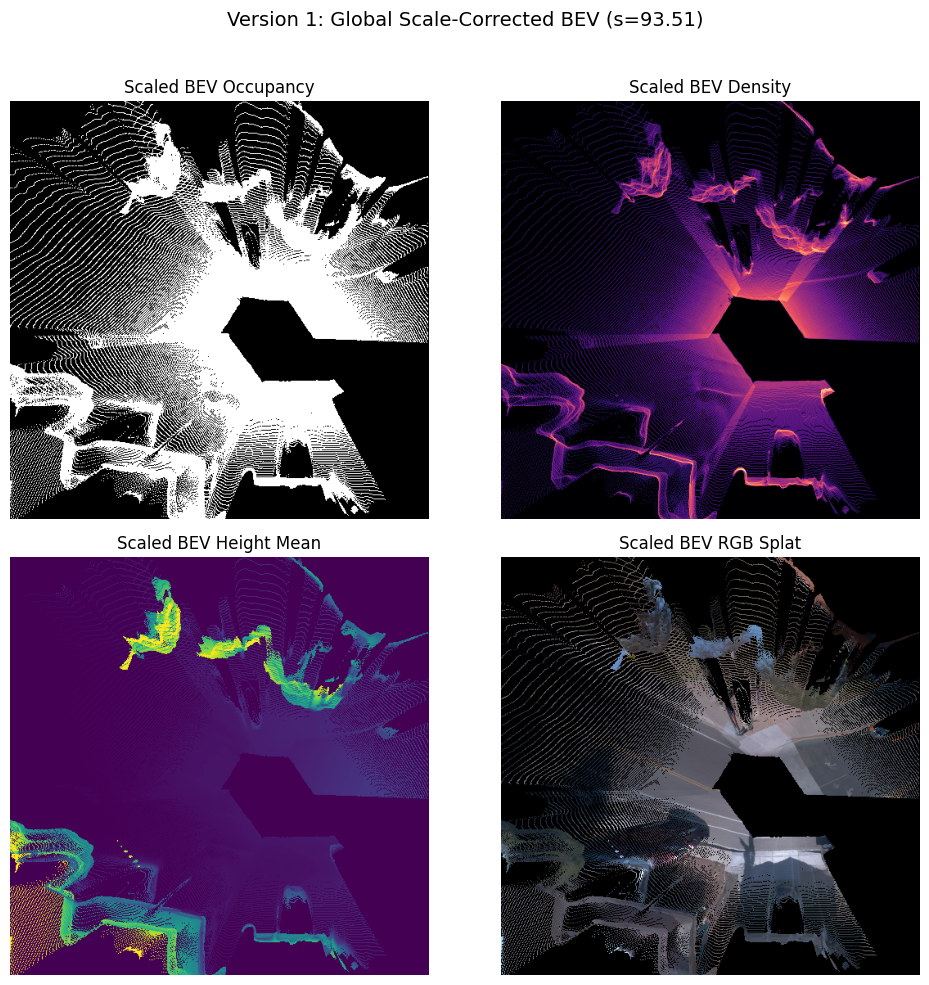

saved scaled BEV overview: D:\Road to st louis\Hustle\CV559\cse559-BEV-Project\notebooks\dust3r_output\frame_000030_5view\bev_lidar_scale_correction\bev_global_scale_corrected.png


In [ ]:
# Cell 17: Generate BEV maps after global scale correction

scaled_bev_out_dir = DUST3R_DIR / "bev_lidar_scale_correction"
scaled_bev_out_dir.mkdir(parents=True, exist_ok=True)

scaled_occupancy, scaled_density, scaled_height_vis, scaled_rgb_bev, scaled_counts, scaled_bev_meta = make_bev_maps(
    scaled_points,
    scaled_colors,
    grid_size=512,
    crop_quantile=0.01,
)

print("Scaled BEV meta:", scaled_bev_meta)
print("occupied cells:", int(scaled_occupancy.sum()))
print("occupancy ratio:", float(scaled_occupancy.mean()))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(scaled_occupancy, cmap="gray")
axes[0, 0].set_title("Scaled BEV Occupancy")
axes[0, 0].axis("off")

axes[0, 1].imshow(scaled_density, cmap="magma")
axes[0, 1].set_title("Scaled BEV Density")
axes[0, 1].axis("off")

axes[1, 0].imshow(scaled_height_vis, cmap="viridis")
axes[1, 0].set_title("Scaled BEV Height Mean")
axes[1, 0].axis("off")

axes[1, 1].imshow(scaled_rgb_bev)
axes[1, 1].set_title("Scaled BEV RGB Splat")
axes[1, 1].axis("off")

fig.suptitle(f"Version 1: Global Scale-Corrected BEV (s={global_scale:.2f})", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

scaled_bev_path = scaled_bev_out_dir / "bev_global_scale_corrected.png"
plt.savefig(scaled_bev_path, dpi=200, bbox_inches="tight")
plt.show()

print("saved scaled BEV overview:", scaled_bev_path)

Global scale correction successfully maps DUSt3R point coordinates to an approximate metric scale using LiDAR supervision. However, because the current BEV visualization uses percentile-based normalization, uniform scaling does not change the relative BEV layout or occupancy ratio. Therefore, global scale alone is mainly useful as metric calibration and initialization, but it is insufficient to improve BEV geometry.

### 3.2 Bundle Adjustment: Sim(3) Alignment + local residual correction
Convert Waymo LiDAR range images into 3D points and fit a Sim(3) transform `p_lidar ≈ s R p_dust3r + t` to correct global scale, rotation, and translation.

In [ ]:
# Cell 18: Prepare LiDAR calibration helpers for range image -> 3D points

import numpy as np
import pandas as pd

# Reuse these columns from earlier cells
RANGE_VALUES_COL = "[LiDARComponent].range_image_return1.values"
RANGE_SHAPE_COL = "[LiDARComponent].range_image_return1.shape"

LIDAR_EXTRINSIC_COL = "[LiDARCalibrationComponent].extrinsic.transform"
BEAM_MIN_COL = "[LiDARCalibrationComponent].beam_inclination.min"
BEAM_MAX_COL = "[LiDARCalibrationComponent].beam_inclination.max"


def reshape_from_values_and_shape(values, shape):
    arr = np.asarray(values)
    shape = tuple(np.asarray(shape, dtype=int).tolist())
    return arr.reshape(shape)


def get_lidar_calib_row(laser_name):
    rows = lidar_calib_df[lidar_calib_df["key.laser_name"] == laser_name]
    if len(rows) == 0:
        raise ValueError(f"No LiDAR calibration found for laser_name={laser_name}")
    return rows.iloc[0]


def get_lidar_extrinsic(calib_row):
    """
    Waymo LiDAR calibration extrinsic transform.
    Usually this maps LiDAR frame points into vehicle frame.
    """
    T = np.asarray(calib_row[LIDAR_EXTRINSIC_COL], dtype=np.float64).reshape(4, 4)
    return T


def get_beam_inclinations(calib_row, H):
    """
    Build vertical beam inclination angles for each range-image row.
    If only min/max are available, approximate them linearly.
    We use max -> min order because range image rows usually go top-to-bottom.
    """
    beam_min = float(calib_row[BEAM_MIN_COL])
    beam_max = float(calib_row[BEAM_MAX_COL])

    inclinations = np.linspace(beam_max, beam_min, H)
    return inclinations

print("LiDAR calibration rows:")
display(lidar_calib_df[[
    "key.laser_name",
    LIDAR_EXTRINSIC_COL,
    BEAM_MIN_COL,
    BEAM_MAX_COL,
]].head())

LiDAR calibration rows:


,key.laser_name,[LiDARCalibrationComponent].extrinsic.transform,[LiDARCalibrationComponent].beam_inclination.min,[LiDARCalibrationComponent].beam_inclination.max
0,2,"[0.99944063871527, 0.026407955471586832, 0.020...",-1.570796,0.523599
1,5,"[-0.9998267946310168, -0.004849705825384812, -...",-1.570796,0.523599
2,3,"[0.02921521772979564, -0.999573142062161, -6.8...",-1.570796,0.523599
3,4,"[0.0035033686124421363, 0.9999900446137231, 0....",-1.570796,0.523599
4,1,"[-0.8524174863304472, -0.5228616354257235, 0.0...",-0.312456,0.042993


In [80]:
# Cell 19: Convert selected-frame LiDAR range images to approximate vehicle-frame 3D points

def range_image_to_vehicle_points(range_img, calib_row):
    """
    Convert one LiDAR range image into approximate vehicle-frame 3D points.

    Note:
        This is an approximate spherical reconstruction, not the official Waymo
        range-image-to-point-cloud conversion.

    Input:
        range_img: H x W x C
        calib_row: one row from lidar_calib_df

    Output:
        xyz_vehicle: H x W x 3
        valid_range: H x W boolean mask
    """
    H, W, C = range_img.shape

    ranges = range_img[..., 0].astype(np.float64)
    valid_range = np.isfinite(ranges) & (ranges > 0)

    # Approximate vertical beam inclinations from calibration min/max
    inclinations = get_beam_inclinations(calib_row, H)  # H

    # Approximate horizontal azimuth angles over 360 degrees
    azimuths = np.linspace(np.pi, -np.pi, W, endpoint=False)  # W

    inc = inclinations[:, None]   # H x 1
    azi = azimuths[None, :]       # 1 x W

    # LiDAR-local spherical-to-Cartesian coordinates
    x_l = ranges * np.cos(inc) * np.cos(azi)
    y_l = ranges * np.cos(inc) * np.sin(azi)
    z_l = ranges * np.sin(inc)

    xyz_lidar = np.stack([x_l, y_l, z_l], axis=-1)  # H x W x 3

    # Transform LiDAR frame -> vehicle frame
    T = get_lidar_extrinsic(calib_row)
    xyz_h = np.concatenate(
        [xyz_lidar, np.ones((H, W, 1), dtype=np.float64)],
        axis=-1
    )

    xyz_vehicle = xyz_h @ T.T
    xyz_vehicle = xyz_vehicle[..., :3]

    # Invalid range points should be NaN
    xyz_vehicle[~valid_range] = np.nan

    return xyz_vehicle.astype(np.float32), valid_range


lidar_xyz_by_laser = {}
lidar_valid_by_laser = {}
summary_rows = []

for laser_name in sorted(lidar_frame_df["key.laser_name"].unique()):
    lidar_row = lidar_frame_df[lidar_frame_df["key.laser_name"] == laser_name].iloc[0]
    calib_row = get_lidar_calib_row(laser_name)

    range_img = reshape_from_values_and_shape(
        lidar_row[RANGE_VALUES_COL],
        lidar_row[RANGE_SHAPE_COL],
    )

    xyz_vehicle, valid_range = range_image_to_vehicle_points(range_img, calib_row)

    lidar_xyz_by_laser[int(laser_name)] = xyz_vehicle
    lidar_valid_by_laser[int(laser_name)] = valid_range

    valid_xyz = xyz_vehicle[valid_range]

    row = {
        "laser_name": int(laser_name),
        "range_shape": str(range_img.shape),
        "xyz_shape": str(xyz_vehicle.shape),
        "valid_points": int(len(valid_xyz)),
    }

    if len(valid_xyz) > 0:
        row.update({
            "x_min": float(np.nanmin(valid_xyz[:, 0])),
            "x_max": float(np.nanmax(valid_xyz[:, 0])),
            "y_min": float(np.nanmin(valid_xyz[:, 1])),
            "y_max": float(np.nanmax(valid_xyz[:, 1])),
            "z_min": float(np.nanmin(valid_xyz[:, 2])),
            "z_max": float(np.nanmax(valid_xyz[:, 2])),
        })
    else:
        row.update({
            "x_min": np.nan,
            "x_max": np.nan,
            "y_min": np.nan,
            "y_max": np.nan,
            "z_min": np.nan,
            "z_max": np.nan,
        })

    summary_rows.append(row)

lidar_3d_summary = pd.DataFrame(summary_rows)
display(lidar_3d_summary)

,laser_name,range_shape,xyz_shape,valid_points,x_min,x_max,y_min,y_max,z_min,z_max
0,1,"(64, 2650, 4)","(64, 2650, 3)",144296,-66.855858,74.533600,-57.114666,67.464973,-5.317470,5.407088
1,2,"(200, 600, 4)","(200, 600, 3)",3639,3.929570,21.764475,-18.532492,18.931108,-0.415663,5.809777
2,3,"(200, 600, 4)","(200, 600, 3)",4072,-16.330210,3.436913,-12.941325,19.054127,-0.381612,6.147970
3,4,"(200, 600, 4)","(200, 600, 3)",3899,-16.030476,3.247714,-18.487715,17.886312,-0.096003,6.315514
4,5,"(200, 600, 4)","(200, 600, 3)",4249,-2.863672,17.645523,-19.801239,19.199135,-0.449559,5.289741


In [ ]:
# Cell 20: Attach LiDAR 3D points to LiDAR-DUSt3R paired samples

pairs_3d = lidar_dust3r_pairs.copy()

lidar_xyz_list = []

for _, row in pairs_3d.iterrows():
    laser_name = int(row["laser_name"])
    r = int(row["range_row"])
    c = int(row["range_col"])

    xyz_map = lidar_xyz_by_laser[laser_name]
    xyz = xyz_map[r, c]

    lidar_xyz_list.append(xyz)

lidar_xyz_arr = np.asarray(lidar_xyz_list, dtype=np.float32)

pairs_3d["lidar_x"] = lidar_xyz_arr[:, 0]
pairs_3d["lidar_y"] = lidar_xyz_arr[:, 1]
pairs_3d["lidar_z"] = lidar_xyz_arr[:, 2]
pairs_3d["lidar_norm"] = np.linalg.norm(lidar_xyz_arr, axis=1)

valid_lidar_xyz = (
    np.isfinite(pairs_3d["lidar_x"]) &
    np.isfinite(pairs_3d["lidar_y"]) &
    np.isfinite(pairs_3d["lidar_z"]) &
    np.isfinite(pairs_3d["lidar_norm"])
)
pairs_3d = pairs_3d[valid_lidar_xyz].copy()

print("\nLiDAR vehicle-frame xyz stats:")
display(pairs_3d[["lidar_x", "lidar_y", "lidar_z", "lidar_norm"]].describe())
print("\nDUSt3R xyz stats:")
display(pairs_3d[["dust3r_x", "dust3r_y", "dust3r_z", "dust3r_norm"]].describe())
print("\nPairs per camera:")
display(pairs_3d["camera_name"].value_counts())
print("\nPairs per laser:")
display(pairs_3d["laser_name"].value_counts())


LiDAR vehicle-frame xyz stats:


,lidar_x,lidar_y,lidar_z,lidar_norm
count,106950.000000,106950.000000,106950.000000,106950.000000
mean,-7.683578,7.483527,-0.107105,22.405121
std,15.061831,18.819736,1.490608,14.011496
min,-66.855858,-51.188133,-4.718538,0.476758
25%,-16.877575,-7.971688,-1.040703,11.354815
50%,-7.093977,6.279044,-0.400187,18.960159
75%,1.048664,17.998549,0.543954,27.862954
max,59.569740,67.464973,6.262786,75.581024



DUSt3R xyz stats:


,dust3r_x,dust3r_y,dust3r_z,dust3r_norm
count,106950.000000,106950.000000,106950.000000,106950.000000
mean,-0.042169,0.011973,0.016541,0.236782
std,0.195358,0.016917,0.192649,0.147288
min,-1.055461,-0.052037,-0.393066,0.055366
25%,-0.117000,-0.000566,-0.140630,0.122551
50%,-0.019512,0.018797,0.023886,0.221518
75%,0.074714,0.026127,0.131447,0.297241
max,1.136969,0.045398,0.663996,1.208926



Pairs per camera:


camera_name
side_left      22962
front_right    22904
front_left     22557
side_right     20218
front          18309
Name: count, dtype: int64


Pairs per laser:


laser_name
1    104887
3       716
2       629
4       611
5       107
Name: count, dtype: int64

This cell reconstructs approximate LiDAR vehicle-frame 3D points from range images. The conversion uses calibration min/max beam inclinations and a uniformly sampled horizontal azimuth, so it should be interpreted as an approximate target rather than the official Waymo point cloud conversion.

In [82]:
# Cell 21: Prepare clean 3D correspondences for Sim(3) fitting

sim3_conf_thresh = 1.9
use_laser1_only = True

sim3_df = pairs_3d.copy()

valid = (
    np.isfinite(sim3_df["dust3r_x"]) &
    np.isfinite(sim3_df["dust3r_y"]) &
    np.isfinite(sim3_df["dust3r_z"]) &
    np.isfinite(sim3_df["lidar_x"]) &
    np.isfinite(sim3_df["lidar_y"]) &
    np.isfinite(sim3_df["lidar_z"]) &
    np.isfinite(sim3_df["dust3r_conf"]) &
    (sim3_df["dust3r_conf"] >= sim3_conf_thresh)
)

if use_laser1_only:
    valid = valid & (sim3_df["laser_name"] == 1)

sim3_df = sim3_df[valid].copy()  # filter to get the training data

print("Sim(3) fitting samples:", len(sim3_df))
print("conf threshold:", sim3_conf_thresh)
print("laser1 only:", use_laser1_only)

print("\nSamples per camera:")
display(sim3_df["camera_name"].value_counts())

print("\nSamples per laser:")
display(sim3_df["laser_name"].value_counts())

print("\nDUSt3R xyz stats:")
display(sim3_df[["dust3r_x", "dust3r_y", "dust3r_z", "dust3r_norm", "dust3r_conf"]].describe())

print("\nLiDAR xyz stats:")
display(sim3_df[["lidar_x", "lidar_y", "lidar_z", "lidar_norm"]].describe())

Sim(3) fitting samples: 85050
conf threshold: 1.9
laser1 only: True

Samples per camera:


camera_name
front_left     20298
front_right    18602
side_left      17169
side_right     16671
front          12310
Name: count, dtype: int64


Samples per laser:


laser_name
1    85050
Name: count, dtype: int64


DUSt3R xyz stats:


,dust3r_x,dust3r_y,dust3r_z,dust3r_norm,dust3r_conf
count,85050.000000,85050.000000,85050.000000,85050.000000,85050.000000
mean,-0.026312,0.014747,0.001125,0.193125,6.194968
std,0.129746,0.015191,0.167135,0.092802,3.213750
min,-0.497406,-0.030902,-0.332922,0.057865,1.900014
25%,-0.099063,0.005691,-0.140825,0.110004,3.513048
50%,-0.015903,0.021058,0.018605,0.184111,5.509081
75%,0.063855,0.026673,0.105017,0.257854,8.212264
max,0.418792,0.039179,0.483664,0.571743,14.623116



LiDAR xyz stats:


,lidar_x,lidar_y,lidar_z,lidar_norm
count,85050.000000,85050.000000,85050.000000,85050.000000
mean,-6.291077,5.717105,-0.259160,18.922495
std,11.506336,15.847968,1.335771,9.980185
min,-44.316345,-22.834551,-3.556272,4.620319
25%,-13.830461,-7.933404,-1.075937,10.616208
50%,-6.806087,5.693801,-0.489502,17.644812
75%,1.595435,14.602505,0.003674,23.977214
max,40.193253,47.759987,4.192891,55.866783


Y ≈ s R X + t

X = DUSt3R points
Y = LiDAR vehicle-frame points

In [83]:
# Cell 22: Fit Sim(3) transform using Umeyama alignment

def fit_sim3_umeyama(X, Y, with_scale=True):
    """
    Fit Sim(3): Y ≈ s * R @ X + t

    X: N x 3 source points, DUSt3R
    Y: N x 3 target points, LiDAR vehicle frame

    Returns:
        s: scalar scale
        R: 3 x 3 rotation matrix
        t: 3-vector translation
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    assert X.shape == Y.shape
    assert X.shape[1] == 3
    n = X.shape[0]
    mu_X = X.mean(axis=0)
    mu_Y = Y.mean(axis=0)
    Xc = X - mu_X
    Yc = Y - mu_Y
    # covariance
    cov = (Yc.T @ Xc) / n
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U @ Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    if with_scale:
        var_X = np.sum(Xc ** 2) / n
        s = np.trace(np.diag(D) @ S) / (var_X + 1e-12)
    else:
        s = 1.0
    t = mu_Y - s * (R @ mu_X)
    return float(s), R, t
# Use all prepared samples, but optionally subsample for speed/stability
fit_df = sim3_df.copy()

max_fit_samples = 50000
if len(fit_df) > max_fit_samples:
    fit_df = fit_df.sample(max_fit_samples, random_state=0)
X = fit_df[["dust3r_x", "dust3r_y", "dust3r_z"]].to_numpy()
Y = fit_df[["lidar_x", "lidar_y", "lidar_z"]].to_numpy()
sim3_scale, sim3_R, sim3_t = fit_sim3_umeyama(X, Y, with_scale=True)
print("Fitted Sim(3)")
print("-" * 60)
print("scale:", sim3_scale)
print("rotation R:")
print(sim3_R)
print("translation t:")
print(sim3_t)

print("\nR det:", np.linalg.det(sim3_R))
print("R orthogonality check ||R^T R - I||:", np.linalg.norm(sim3_R.T @ sim3_R - np.eye(3)))

Fitted Sim(3)
------------------------------------------------------------
scale: 87.80635826900698
rotation R:
[[ 0.99970383  0.01869499  0.01558066]
 [-0.01528996 -0.01559319  0.99976151]
 [ 0.01893348 -0.99970363 -0.01530273]]
translation t:
[-4.01804505  5.59157744  1.07865168]

R det: 0.9999999999999997
R orthogonality check ||R^T R - I||: 6.483615906909896e-16


In [84]:
# Cell 23: Evaluate Sim(3) alignment error

eval_df = sim3_df.copy()

X_eval = eval_df[["dust3r_x", "dust3r_y", "dust3r_z"]].to_numpy()
Y_eval = eval_df[["lidar_x", "lidar_y", "lidar_z"]].to_numpy()
Y_pred = sim3_scale * (X_eval @ sim3_R.T) + sim3_t[None, :]

err_vec = Y_pred - Y_eval
err_dist = np.linalg.norm(err_vec, axis=1)

eval_df["sim3_pred_x"] = Y_pred[:, 0]
eval_df["sim3_pred_y"] = Y_pred[:, 1]
eval_df["sim3_pred_z"] = Y_pred[:, 2]
eval_df["sim3_error"] = err_dist

print("Sim(3) alignment error stats:")
display(eval_df["sim3_error"].describe())

print("\nError by camera:")
display(
    eval_df.groupby("camera_name")["sim3_error"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median")
)

print("\nCompare with scale-only radial error from Version 1:")

# radial scale-only error from previous version, using global scale on norm
scale_only_pred_range = scale_ls * eval_df["dust3r_norm"].to_numpy()
scale_only_range_err = np.abs(scale_only_pred_range - eval_df["lidar_range"].to_numpy())
compare_df = pd.DataFrame({
    "Method": ["Scale-only radial", "Sim(3) 3D"],
    "Mean Error": [scale_only_range_err.mean(), err_dist.mean()],
    "Median Error": [np.median(scale_only_range_err), np.median(err_dist)],
    "RMSE": [
        np.sqrt(np.mean(scale_only_range_err ** 2)),
        np.sqrt(np.mean(err_dist ** 2)),
    ],
})

display(compare_df)

Sim(3) alignment error stats:


count    85050.000000
mean         5.471199
std          2.997757
min          0.250345
25%          3.601028
50%          4.991568
75%          6.554766
max         27.811638
Name: sim3_error, dtype: float64


Error by camera:


,count,mean,median,std,min,max
camera_name,,,,,,
front_left,20298,4.253764,3.519849,2.594370,0.250345,22.070269
front_right,18602,4.921933,4.687641,2.476247,0.329885,18.916890
side_right,16671,6.568043,5.108329,4.402431,0.256854,27.811638
front,12310,5.138287,5.302137,1.053256,2.187700,19.626046
side_left,17169,6.679284,6.413645,2.348723,1.512320,14.631803



Compare with scale-only radial error from Version 1:


,Method,Mean Error,Median Error,RMSE
0,Scale-only radial,3.229758,2.194759,4.337103
1,Sim(3) 3D,5.471199,4.991568,6.238627


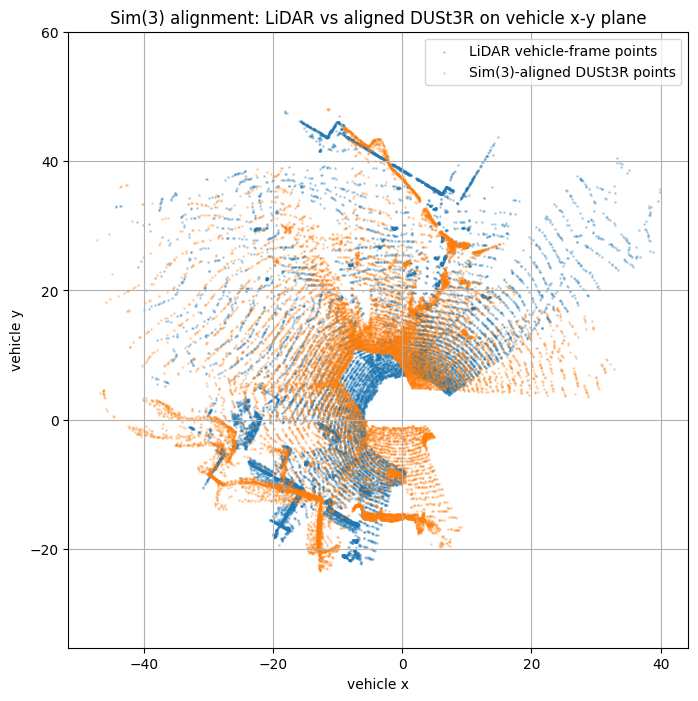

In [85]:
# Cell 24: Visualize Sim(3)-aligned DUSt3R points vs LiDAR points on vehicle x-y plane

plot_eval = eval_df.copy()

if len(plot_eval) > 20000:
    plot_eval = plot_eval.sample(20000, random_state=0)

plt.figure(figsize=(8, 8))

plt.scatter(
    plot_eval["lidar_x"],
    plot_eval["lidar_y"],
    s=1,
    alpha=0.25,
    label="LiDAR vehicle-frame points"
)

plt.scatter(
    plot_eval["sim3_pred_x"],
    plot_eval["sim3_pred_y"],
    s=1,
    alpha=0.25,
    label="Sim(3)-aligned DUSt3R points"
)

plt.xlabel("vehicle x")
plt.ylabel("vehicle y")
plt.title("Sim(3) alignment: LiDAR vs aligned DUSt3R on vehicle x-y plane")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate pre-Sim(3) vs Sim(3) initialization on residual samples

def smooth_l1_mean_np(pred, target, beta=1.0):
    """
    NumPy version of SmoothL1Loss(beta=1.0, reduction='mean').
    This matches the position/range loss style used in local residual optimization.
    """
    diff = np.abs(pred - target)
    loss = np.where(diff < beta, 0.5 * diff**2 / beta, diff - 0.5 * beta)
    return float(loss.mean())


def error_summary(pred_points, target_points, method_name):
    """
    Compute 3D position error, radial/range error, and SmoothL1 losses.
    """
    pred_points = np.asarray(pred_points, dtype=np.float64)
    target_points = np.asarray(target_points, dtype=np.float64)

    err_3d = np.linalg.norm(pred_points - target_points, axis=1)

    pred_norm = np.linalg.norm(pred_points, axis=1)
    target_norm = np.linalg.norm(target_points, axis=1)
    err_range = np.abs(pred_norm - target_norm)

    pos_loss = smooth_l1_mean_np(pred_points, target_points, beta=1.0)
    range_loss = smooth_l1_mean_np(pred_norm, target_norm, beta=1.0)

    # Same weighting used at the start of local residual optimization.
    # smooth_loss and mag_loss are zero before learning residual deltas.
    local_init_loss = pos_loss + 0.5 * range_loss

    return {
        "Method": method_name,
        "Mean 3D Error": err_3d.mean(),
        "Median 3D Error": np.median(err_3d),
        "3D RMSE": np.sqrt(np.mean(err_3d ** 2)),
        "Mean Range Error": err_range.mean(),
        "Median Range Error": np.median(err_range),
        "Range RMSE": np.sqrt(np.mean(err_range ** 2)),
        "SmoothL1 Pos Loss": pos_loss,
        "SmoothL1 Range Loss": range_loss,
        "Local Init Loss": local_init_loss,
    }


# Use the exact same samples that will be used for local residual optimization
X_res = res_df[["dust3r_x", "dust3r_y", "dust3r_z"]].to_numpy(dtype=np.float64)
Y_res = res_df[["lidar_x", "lidar_y", "lidar_z"]].to_numpy(dtype=np.float64)

# 1. Raw DUSt3R coordinates: arbitrary DUSt3R frame, not vehicle-aligned
P_raw = X_res

# 2. Scale-only coordinates: metric magnitude corrected, but no rotation/translation
P_scale_only = scale_ls * X_res

# 3. Sim(3)-aligned coordinates: global scale + rotation + translation
P_sim3_init = sim3_scale * (X_res @ sim3_R.T) + sim3_t[None, :]

init_compare_df = pd.DataFrame([
    error_summary(P_raw, Y_res, "Raw DUSt3R coordinates"),
    error_summary(P_scale_only, Y_res, "Scale-only, no R/t"),
    error_summary(P_sim3_init, Y_res, "Sim(3) initialization"),
])

display(init_compare_df)

print("Notes:")
print("- Raw and scale-only 3D errors are measured against LiDAR vehicle-frame points, so they expose coordinate-frame mismatch.")
print("- Sim(3) should reduce the 3D vehicle-frame error if the global alignment is meaningful.")
print("- The 'Local Init Loss' uses the same pos + 0.5 * range objective used at the start of local residual optimization, without smooth/magnitude regularization.")

,Method,Mean 3D Error,Median 3D Error,3D RMSE,Mean Range Error,Median Range Error,Range RMSE,SmoothL1 Pos Loss,SmoothL1 Range Loss,Local Init Loss
0,Raw DUSt3R coordinates,18.658018,17.432292,21.145146,18.535081,17.307102,21.009730,7.792544,18.035084,16.810086
1,"Scale-only, no R/t",19.765398,17.200419,23.539199,3.376685,2.469786,4.503187,9.711310,2.917133,11.169876
2,Sim(3) initialization,5.767437,5.042720,6.901411,3.779127,3.364346,4.730010,2.239718,3.301442,3.890439


Notes:
- Raw and scale-only 3D errors are measured against LiDAR vehicle-frame points, so they expose coordinate-frame mismatch.
- Sim(3) should reduce the 3D vehicle-frame error if the global alignment is meaningful.
- The 'Local Init Loss' uses the same pos + 0.5 * range objective used at the start of local residual optimization, without smooth/magnitude regularization.


This comparison shows why the local residual correction is initialized from Sim(3) rather than from scale-only correction. Scale-only correction greatly reduces the radial/range error, but it does not solve the global rotation and translation mismatch between DUSt3R coordinates and the approximate LiDAR vehicle frame. As a result, its 3D position error remains high. In contrast, Sim(3) significantly reduces the 3D position error and gives the lowest local initialization loss, making it a better coarse alignment before learning local residual corrections.

In [88]:
# Cell 27: Prepare data for LiDAR-guided local residual optimization

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

res_conf_thresh = 1.9
res_use_laser1_only = False   # use all available LiDAR supervision

res_df = pairs_3d.copy()

valid = (
    np.isfinite(res_df["dust3r_x"]) &
    np.isfinite(res_df["dust3r_y"]) &
    np.isfinite(res_df["dust3r_z"]) &
    np.isfinite(res_df["lidar_x"]) &
    np.isfinite(res_df["lidar_y"]) &
    np.isfinite(res_df["lidar_z"]) &
    np.isfinite(res_df["dust3r_conf"]) &
    np.isfinite(res_df["u_dust3r"]) &
    np.isfinite(res_df["v_dust3r"]) &
    np.isfinite(res_df["dust3r_width"]) &
    np.isfinite(res_df["dust3r_height"]) &
    (res_df["dust3r_conf"] >= res_conf_thresh)
)

if res_use_laser1_only:
    valid = valid & (res_df["laser_name"] == 1)

res_df = res_df[valid].copy().reset_index(drop=True)

# Use the same view order as DUSt3R output
res_view_names = list(view_names)
res_view_to_idx = {name: i for i, name in enumerate(res_view_names)}
res_df["res_view_idx"] = res_df["camera_name"].map(res_view_to_idx)

# Drop anything not in current 5-view DUSt3R outputs
res_df = res_df[np.isfinite(res_df["res_view_idx"])].copy()
res_df["res_view_idx"] = res_df["res_view_idx"].astype(int)


display(res_df["camera_name"].value_counts())
display(res_df["laser_name"].value_counts())
display(res_df.head())

camera_name
front_left     20724
front_right    19164
side_left      17578
side_right     16875
front          12656
Name: count, dtype: int64

laser_name
1    85050
3      663
2      608
4      594
5       82
Name: count, dtype: int64

,laser_name,proj_slot,range_row,range_col,lidar_range,camera_id,camera_name,u_orig,v_orig,orig_width,...,dust3r_x,dust3r_y,dust3r_z,dust3r_norm,dust3r_conf,lidar_x,lidar_y,lidar_z,lidar_norm,res_view_idx
0,1,0,0,1418,31.302549,1,front,1413.0,562.0,1920,...,-0.179770,-0.015398,0.211729,0.278179,2.761003,-21.005726,21.789583,3.488545,30.466316,2
1,1,0,0,1419,31.343536,1,front,1418.0,562.0,1920,...,-0.178499,-0.015344,0.211488,0.277172,2.925097,-20.983316,21.871319,3.490114,30.509590,2
2,1,0,0,1420,31.279127,1,front,1424.0,561.0,1920,...,-0.177438,-0.016048,0.212361,0.277198,2.199017,-20.885452,21.879347,3.487291,30.447811,2
3,1,0,0,1461,38.797359,1,front,1642.0,561.0,1920,...,-0.165916,-0.016424,0.264012,0.312250,3.254963,-23.484858,29.696695,3.793739,38.050293,2
4,1,0,0,1462,38.118141,1,front,1647.0,561.0,1920,...,-0.165038,-0.016381,0.264067,0.311829,3.530525,-22.979439,29.234758,3.765400,37.375179,2


In [ ]:
# Cell 28: Optimize local residual correction field

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

grid_h = 16
grid_w = 16

class LocalResidualScaleField(nn.Module):
    def __init__(self, num_views, grid_h=16, grid_w=16):
        super().__init__()
        self.num_views = num_views
        self.grid_h = grid_h
        self.grid_w = grid_w

        # delta initialized to zero, so exp(delta)=1 initially
        self.delta = nn.Parameter(
            torch.zeros(num_views, grid_h, grid_w, dtype=torch.float32)
        )

    def forward(self, p_sim3, view_idx, cell_y, cell_x):
        delta_vals = self.delta[view_idx, cell_y, cell_x].unsqueeze(1)
        residual_scale = torch.exp(delta_vals)
        p_corrected = p_sim3 * residual_scale
        return p_corrected

    def smoothness_loss(self):
        dx = self.delta[:, :, 1:] - self.delta[:, :, :-1]
        dy = self.delta[:, 1:, :] - self.delta[:, :-1, :]
        return (dx ** 2).mean() + (dy ** 2).mean()

    def magnitude_loss(self):
        return (self.delta ** 2).mean()

# DUSt3R points
X_np = res_df[["dust3r_x", "dust3r_y", "dust3r_z"]].to_numpy(dtype=np.float32)

# LiDAR target points
Y_np = res_df[["lidar_x", "lidar_y", "lidar_z"]].to_numpy(dtype=np.float32)

# Apply global Sim(3) initialization first
p_sim3_np = sim3_scale * (X_np @ sim3_R.T) + sim3_t[None, :]

# View indices
view_idx_np = res_df["res_view_idx"].to_numpy(dtype=np.int64)

# Compute coarse image-grid cell index from DUSt3R resized pixel
u = res_df["u_dust3r"].to_numpy(dtype=np.float32)
v = res_df["v_dust3r"].to_numpy(dtype=np.float32)
w = res_df["dust3r_width"].to_numpy(dtype=np.float32)
h = res_df["dust3r_height"].to_numpy(dtype=np.float32)

cell_x_np = np.floor(u / np.maximum(w, 1) * grid_w).astype(np.int64)
cell_y_np = np.floor(v / np.maximum(h, 1) * grid_h).astype(np.int64)

cell_x_np = np.clip(cell_x_np, 0, grid_w - 1)
cell_y_np = np.clip(cell_y_np, 0, grid_h - 1)

# Tensors
P_sim3 = torch.from_numpy(p_sim3_np.astype(np.float32)).to(device)
Y_t = torch.from_numpy(Y_np).to(device)
view_idx_t = torch.from_numpy(view_idx_np).to(device)
cell_x_t = torch.from_numpy(cell_x_np).to(device)
cell_y_t = torch.from_numpy(cell_y_np).to(device)

num_views = len(res_view_names)

res_model = LocalResidualScaleField(
    num_views=num_views,
    grid_h=grid_h,
    grid_w=grid_w,
).to(device)

print("initialized res_model")
print("num_views:", num_views)
print("grid_h, grid_w:", grid_h, grid_w)

optimizer = optim.Adam(res_model.parameters(), lr=0.05)

loss_fn = nn.SmoothL1Loss(beta=1.0)

# Loss weights
pos_weight = 1.0
range_weight = 0.5
smooth_weight = 0.1
mag_weight = 0.05

num_iters = 100
print_every = 10

loss_rows = []

for it in range(num_iters):
    optimizer.zero_grad()

    P_corr = res_model(P_sim3, view_idx_t, cell_y_t, cell_x_t)

    # 3D position loss
    pos_loss = loss_fn(P_corr, Y_t)

    # Range / depth-like loss
    pred_norm = torch.linalg.norm(P_corr, dim=1)
    target_norm = torch.linalg.norm(Y_t, dim=1)
    range_loss = loss_fn(pred_norm, target_norm)

    smooth_loss = res_model.smoothness_loss()
    mag_loss = res_model.magnitude_loss()

    loss = (
        pos_weight * pos_loss +
        range_weight * range_loss +
        smooth_weight * smooth_loss +
        mag_weight * mag_loss
    )
    loss.backward()
    optimizer.step()
    row = {
        "iter": it,
        "loss": float(loss.detach().cpu()),
        "pos_loss": float(pos_loss.detach().cpu()),
        "range_loss": float(range_loss.detach().cpu()),
        "smooth_loss": float(smooth_loss.detach().cpu()),
        "mag_loss": float(mag_loss.detach().cpu()),
    }
    loss_rows.append(row)

    if it % print_every == 0 or it == num_iters - 1:
        print(
            f"iter {it:04d} | "
            f"loss={row['loss']:.4f} | "
            f"pos={row['pos_loss']:.4f} | "
            f"range={row['range_loss']:.4f} | "
            f"smooth={row['smooth_loss']:.4f} | "
            f"mag={row['mag_loss']:.4f}"
        )

res_loss_df = pd.DataFrame(loss_rows)
display(res_loss_df.tail())

delta_np = res_model.delta.detach().cpu().numpy()
print("delta stats:")
print("min:", delta_np.min(), "max:", delta_np.max(), "mean:", delta_np.mean(), "std:", delta_np.std())
print("residual scale stats exp(delta):")
print("min:", np.exp(delta_np).min(), "max:", np.exp(delta_np).max(), "mean:", np.exp(delta_np).mean())

device: cuda
initialized res_model
num_views: 5
grid_h, grid_w: 16 16
iter 0000 | loss=3.8904 | pos=2.2397 | range=3.3014 | smooth=0.0000 | mag=0.0000
iter 0010 | loss=1.8874 | pos=1.5062 | range=0.7527 | smooth=0.0109 | mag=0.0758
iter 0020 | loss=1.7626 | pos=1.4571 | range=0.5988 | smooth=0.0141 | mag=0.0942
iter 0030 | loss=1.6931 | pos=1.4450 | range=0.4855 | smooth=0.0122 | mag=0.0838
iter 0040 | loss=1.6741 | pos=1.4406 | range=0.4567 | smooth=0.0107 | mag=0.0809
iter 0050 | loss=1.6651 | pos=1.4376 | range=0.4442 | smooth=0.0112 | mag=0.0838
iter 0060 | loss=1.6620 | pos=1.4358 | range=0.4420 | smooth=0.0111 | mag=0.0833
iter 0070 | loss=1.6609 | pos=1.4365 | range=0.4382 | smooth=0.0109 | mag=0.0830
iter 0080 | loss=1.6604 | pos=1.4360 | range=0.4385 | smooth=0.0110 | mag=0.0831
iter 0090 | loss=1.6603 | pos=1.4361 | range=0.4379 | smooth=0.0109 | mag=0.0831
iter 0099 | loss=1.6602 | pos=1.4362 | range=0.4377 | smooth=0.0110 | mag=0.0831


,iter,loss,pos_loss,range_loss,smooth_loss,mag_loss
95,95,1.660255,1.436071,0.437863,0.010957,0.083138
96,96,1.660251,1.436071,0.437854,0.010963,0.083136
97,97,1.660247,1.436087,0.437813,0.010966,0.083130
98,98,1.660241,1.436117,0.437743,0.010968,0.083120
99,99,1.660236,1.436151,0.437665,0.010968,0.083108


delta stats:
min: -0.68139505 max: 1.3655928 mean: 0.026104402 std: 0.2870746
residual scale stats exp(delta):
min: 0.5059107 max: 3.9180453 mean: 1.0731293


In [ ]:
# Cell 29: Evaluate local residual correction

res_model.eval()

with torch.no_grad():
    P_corr = res_model(P_sim3, view_idx_t, cell_y_t, cell_x_t).detach().cpu().numpy()

Y_true = Y_np

res_err = np.linalg.norm(P_corr - Y_true, axis=1)

res_eval_df = res_df.copy()
res_eval_df["sim3_x"] = p_sim3_np[:, 0]
res_eval_df["sim3_y"] = p_sim3_np[:, 1]
res_eval_df["sim3_z"] = p_sim3_np[:, 2]

res_eval_df["res_corr_x"] = P_corr[:, 0]
res_eval_df["res_corr_y"] = P_corr[:, 1]
res_eval_df["res_corr_z"] = P_corr[:, 2]
res_eval_df["res_error"] = res_err

# Basic Sim(3) error on same samples
sim3_err_same = np.linalg.norm(p_sim3_np - Y_true, axis=1)

# Scale-only radial error on same samples
scale_only_pred_range = scale_ls * res_eval_df["dust3r_norm"].to_numpy()
scale_only_range_err = np.abs(scale_only_pred_range - res_eval_df["lidar_range"].to_numpy())

print("Local residual correction error stats:")
display(res_eval_df["res_error"].describe())

print("\nError by camera:")
display(
    res_eval_df.groupby("camera_name")["res_error"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median")
)

compare_res_df = pd.DataFrame([
    {
        "Method": "Scale-only radial",
        "Error Type": "1D range error",
        "Mean Error": scale_only_range_err.mean(),
        "Median Error": np.median(scale_only_range_err),
        "RMSE": np.sqrt(np.mean(scale_only_range_err ** 2)),
    },
    {
        "Method": "Basic Sim(3)",
        "Error Type": "3D position error",
        "Mean Error": sim3_err_same.mean(),
        "Median Error": np.median(sim3_err_same),
        "RMSE": np.sqrt(np.mean(sim3_err_same ** 2)),
    },
    {
        "Method": "Local residual correction",
        "Error Type": "3D position error",
        "Mean Error": res_err.mean(),
        "Median Error": np.median(res_err),
        "RMSE": np.sqrt(np.mean(res_err ** 2)),
    },
])

display(compare_res_df)

Local residual correction error stats:


count    86997.000000
mean         3.992081
std          3.694243
min          0.052843
25%          1.591982
50%          2.973860
75%          5.246707
max         47.355675
Name: res_error, dtype: float64


Error by camera:


,count,mean,median,std,min,max
camera_name,,,,,,
front,12656,2.068154,1.378613,2.972727,0.187014,41.743988
front_right,19164,3.674617,2.469811,3.949156,0.052843,47.355675
front_left,20724,2.967453,2.674272,2.958605,0.077659,43.224110
side_right,16875,4.437309,3.643853,3.646067,0.423700,36.198757
side_left,17578,6.503986,6.253070,3.253603,0.643508,41.749378


,Method,Error Type,Mean Error,Median Error,RMSE
0,Scale-only radial,1D range error,3.191974,2.176473,4.299796
1,Basic Sim(3),3D position error,5.767437,5.042720,6.901411
2,Local residual correction,3D position error,3.992081,2.973860,5.439116


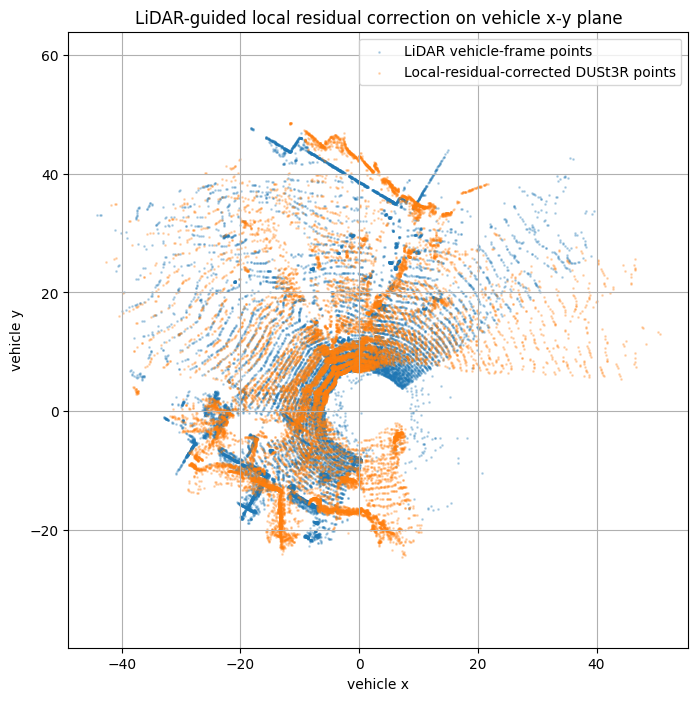

In [ ]:
# Cell 30: Visualize LiDAR vs local-residual-corrected DUSt3R samples

plot_df = res_eval_df.copy()

if len(plot_df) > 20000:
    plot_df = plot_df.sample(20000, random_state=0)

plt.figure(figsize=(8, 8))

plt.scatter(
    plot_df["lidar_x"],
    plot_df["lidar_y"],
    s=1,
    alpha=0.25,
    label="LiDAR vehicle-frame points"
)

plt.scatter(
    plot_df["res_corr_x"],
    plot_df["res_corr_y"],
    s=1,
    alpha=0.25,
    label="Local-residual-corrected DUSt3R points"
)

plt.xlabel("vehicle x")
plt.ylabel("vehicle y")
plt.title("LiDAR-guided local residual correction on vehicle x-y plane")
plt.axis("equal")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Cell 31: Apply local residual correction to all DUSt3R pointmaps

corrected_all_points = []
corrected_all_colors = []
corrected_all_confs = []

conf_thresh_apply = 1.9

delta_np = res_model.delta.detach().cpu().numpy()

for i, name in enumerate(view_names):
    pts = pts3d_np[i]      # H x W x 3
    img = imgs_np[i]       # H x W x 3
    conf = conf_np[i]      # H x W

    H, W = conf.shape

    pts_flat = pts.reshape(-1, 3)
    colors_flat = img.reshape(-1, 3)
    conf_flat = conf.reshape(-1)

    valid = (
        np.isfinite(pts_flat).all(axis=1) &
        np.isfinite(colors_flat).all(axis=1) &
        np.isfinite(conf_flat) &
        (conf_flat >= conf_thresh_apply)
    )

    # Sim(3) transform all points into vehicle-like frame
    pts_sim3 = sim3_scale * (pts_flat @ sim3_R.T) + sim3_t[None, :]

    # Build cell index for every pixel
    yy, xx = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    xx_flat = xx.reshape(-1)
    yy_flat = yy.reshape(-1)

    cell_x = np.floor(xx_flat / max(W, 1) * grid_w).astype(np.int64)
    cell_y = np.floor(yy_flat / max(H, 1) * grid_h).astype(np.int64)

    cell_x = np.clip(cell_x, 0, grid_w - 1)
    cell_y = np.clip(cell_y, 0, grid_h - 1)

    residual_scale = np.exp(delta_np[i, cell_y, cell_x])[:, None]
    pts_corrected = pts_sim3 * residual_scale

    pts_corrected = pts_corrected[valid]
    colors_keep = colors_flat[valid]
    conf_keep = conf_flat[valid]

    corrected_all_points.append(pts_corrected)
    corrected_all_colors.append(colors_keep)
    corrected_all_confs.append(conf_keep)

    print(f"{name:12s} kept corrected points: {len(pts_corrected)}")

corrected_points = np.concatenate(corrected_all_points, axis=0)
corrected_colors = np.concatenate(corrected_all_colors, axis=0)
corrected_confs = np.concatenate(corrected_all_confs, axis=0)

print("-" * 60)
print("corrected points:", corrected_points.shape)
print("corrected colors:", corrected_colors.shape)
print("corrected confs:", corrected_confs.shape)
print("x range:", corrected_points[:, 0].min(), corrected_points[:, 0].max())
print("y range:", corrected_points[:, 1].min(), corrected_points[:, 1].max())
print("z range:", corrected_points[:, 2].min(), corrected_points[:, 2].max())
print("conf range:", corrected_confs.min(), corrected_confs.max())

side_left    kept corrected points: 91404
front_left   kept corrected points: 118245
front        kept corrected points: 85414
front_right  kept corrected points: 141310
side_right   kept corrected points: 88583
------------------------------------------------------------
corrected points: (524956, 3)
corrected colors: (524956, 3)
corrected confs: (524956,)
x range: -45.80336624181332 52.595459867347365
y range: -27.115110920081726 48.61752493687441
z range: -4.082815408171356 12.085470316267758
conf range: 1.9000138 14.663202


Corrected vehicle-frame BEV meta: {'x_min': np.float64(-32.47428529870479), 'x_max': np.float64(23.472307408461972), 'y_min': np.float64(-20.86838781766421), 'y_max': np.float64(42.92394351283521), 'num_points_used': 503956, 'grid_size': 512}
occupied cells: 84357
occupancy ratio: 0.3217964172363281
Saved figure to: D:\Road to st louis\Hustle\CV559\cse559-BEV-Project\notebooks\dust3r_output\frame_000030_5view\bev_lidar_local_residual\bev_sim3_local_residual_correction.png


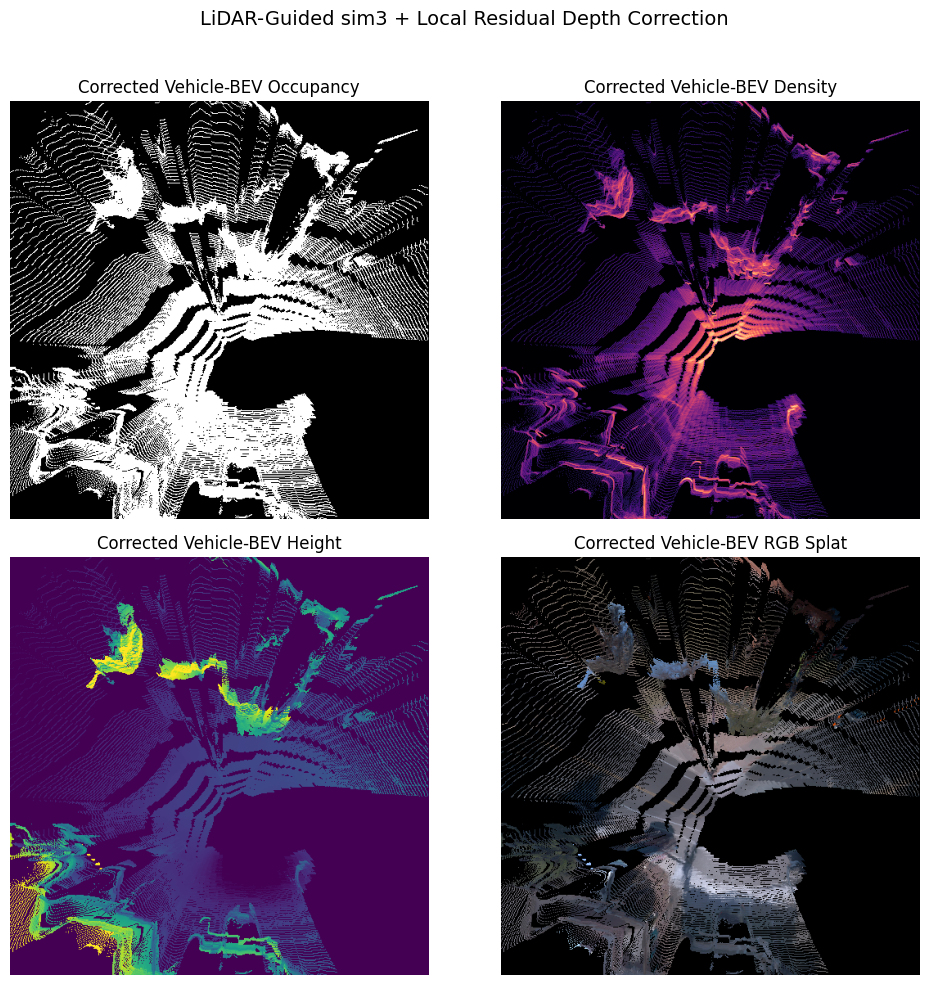

In [90]:
# Cell 32: Generate BEV in vehicle-frame x-y plane

def make_vehicle_bev_maps(
    points,
    colors,
    grid_size=512,
    crop_quantile=0.01,
):
    """
    Project vehicle-frame points to BEV using x-y ground plane.
    z is treated as height.
    """

    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    x_min, x_max = np.quantile(x, [crop_quantile, 1 - crop_quantile])
    y_min, y_max = np.quantile(y, [crop_quantile, 1 - crop_quantile])

    valid = (
        (x >= x_min) & (x <= x_max) &
        (y >= y_min) & (y <= y_max) &
        np.isfinite(points).all(axis=1)
    )

    pts = points[valid]
    cols = colors[valid].astype(np.float32)

    x = pts[:, 0]
    y = pts[:, 1]
    z = pts[:, 2]

    gx = ((x - x_min) / (x_max - x_min + 1e-8) * (grid_size - 1)).astype(np.int32)
    gy = ((y - y_min) / (y_max - y_min + 1e-8) * (grid_size - 1)).astype(np.int32)

    gx = np.clip(gx, 0, grid_size - 1)
    gy = np.clip(gy, 0, grid_size - 1)

    row = grid_size - 1 - gy
    col = gx

    counts = np.zeros((grid_size, grid_size), dtype=np.float32)
    height_sum = np.zeros((grid_size, grid_size), dtype=np.float32)
    rgb_sum = np.zeros((grid_size, grid_size, 3), dtype=np.float32)

    np.add.at(counts, (row, col), 1)
    np.add.at(height_sum, (row, col), z)
    np.add.at(rgb_sum, (row, col), cols)

    occupancy = (counts > 0).astype(np.float32)

    density = np.log1p(counts)
    if density.max() > 0:
        density = density / density.max()

    height_mean = np.zeros_like(height_sum)
    valid_cells = counts > 0
    height_mean[valid_cells] = height_sum[valid_cells] / counts[valid_cells]

    height_vis = np.zeros_like(height_mean)
    if valid_cells.any():
        h_vals = height_mean[valid_cells]
        h_low, h_high = np.quantile(h_vals, [0.02, 0.98])
        height_vis = np.clip((height_mean - h_low) / (h_high - h_low + 1e-8), 0, 1)
        height_vis[~valid_cells] = 0

    rgb_bev = np.zeros_like(rgb_sum)
    rgb_bev[valid_cells] = rgb_sum[valid_cells] / counts[valid_cells, None]
    rgb_bev = np.clip(rgb_bev, 0, 1)

    meta = {
        "x_min": x_min,
        "x_max": x_max,
        "y_min": y_min,
        "y_max": y_max,
        "num_points_used": int(valid.sum()),
        "grid_size": grid_size,
    }

    return occupancy, density, height_vis, rgb_bev, counts, meta


corr_occupancy, corr_density, corr_height_vis, corr_rgb_bev, corr_counts, corr_bev_meta = make_vehicle_bev_maps(
    corrected_points,
    corrected_colors,
    grid_size=512,
    crop_quantile=0.01,
)

print("Corrected vehicle-frame BEV meta:", corr_bev_meta)
print("occupied cells:", int(corr_occupancy.sum()))
print("occupancy ratio:", float(corr_occupancy.mean()))

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(corr_occupancy, cmap="gray")
axes[0, 0].set_title("Corrected Vehicle-BEV Occupancy")
axes[0, 0].axis("off")

axes[0, 1].imshow(corr_density, cmap="magma")
axes[0, 1].set_title("Corrected Vehicle-BEV Density")
axes[0, 1].axis("off")

axes[1, 0].imshow(corr_height_vis, cmap="viridis")
axes[1, 0].set_title("Corrected Vehicle-BEV Height")
axes[1, 0].axis("off")

axes[1, 1].imshow(corr_rgb_bev)
axes[1, 1].set_title("Corrected Vehicle-BEV RGB Splat")
axes[1, 1].axis("off")

fig.suptitle("LiDAR-Guided sim3 + Local Residual Depth Correction", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
local_residual_out_dir = DUST3R_DIR / "bev_lidar_local_residual"
local_residual_out_dir.mkdir(parents=True, exist_ok=True)

fig_path = local_residual_out_dir / "bev_sim3_local_residual_correction.png"

fig.savefig(fig_path, dpi=200, bbox_inches="tight")
print("Saved figure to:", fig_path)

plt.show()